<a href="https://colab.research.google.com/github/Aayush-Tiwari-1/Predicting-Customer-Margin-Loss-and-Its-Impact-on-Profit/blob/main/Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_excel('/content/synthetic_retail_margin_data.xlsx')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, white background style for professional reports
sns.set_theme(style="whitegrid")
sns.set_palette("husl")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

# Assuming 'df' is already loaded from the previous data generation step

In [ ]:
df.describe()

,customer_id,list_price,discount_rate,cogs_ratio,competitor_intensity,shipping_distance_km,sales_revenue,cogs_amount,shipping_cost,return_probability,expected_return_cost,total_cost,pocket_profit,pocket_margin_pct,margin_loss,discount_x_cogs,cost_burden,cluster_id
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,2519.580662,0.148567,0.550883,0.546404,494.912601,2143.372428,1386.243146,124.236890,0.067311,143.971803,1654.451838,488.920590,0.164344,0.468600,0.081769,0.835656,1.361200
std,2886.89568,2411.232829,0.099376,0.117893,0.259877,488.408845,2068.373966,1370.227989,73.261327,0.048951,197.572736,1505.400374,800.054452,0.226408,0.499038,0.058821,0.226408,0.986627
min,1.00000,99.920040,0.000125,0.250000,0.100026,0.048953,63.147047,39.483573,50.007343,-0.027052,0.000000,105.989103,-2801.412274,-1.879613,0.000000,0.000070,0.312936,0.000000
25%,2500.75000,1058.053096,0.070249,0.469155,0.319856,141.084305,892.707459,556.538839,71.162646,0.033398,34.105945,747.346361,49.658498,0.050135,0.000000,0.036847,0.686416,0.000000
50%,5000.50000,1818.469729,0.130258,0.552199,0.548656,347.021223,1544.753193,977.650689,102.053183,0.053252,80.791137,1217.454751,273.794148,0.191893,0.000000,0.069216,0.808107,2.000000
75%,7500.25000,3154.924290,0.209465,0.631459,0.769097,689.636929,2679.356819,1725.280957,153.445539,0.088570,175.497777,2035.422153,663.544544,0.313584,1.000000,0.112876,0.949865,2.000000
max,10000.00000,38001.233279,0.582103,0.850000,0.999978,4200.658737,33715.112294,24860.601492,680.098810,0.183177,4868.454962,26111.283876,14884.957322,0.687064,1.000000,0.429295,2.879613,3.000000


In [ ]:
df.shape


(10000, 23)

In [ ]:
df.isna().sum()

,0
customer_id,0
segment,0
category,0
list_price,0
discount_rate,0
cogs_ratio,0
competitor_intensity,0
shipping_distance_km,0
sales_revenue,0
cogs_amount,0


In [ ]:
df.duplicated().sum()

np.int64(0)

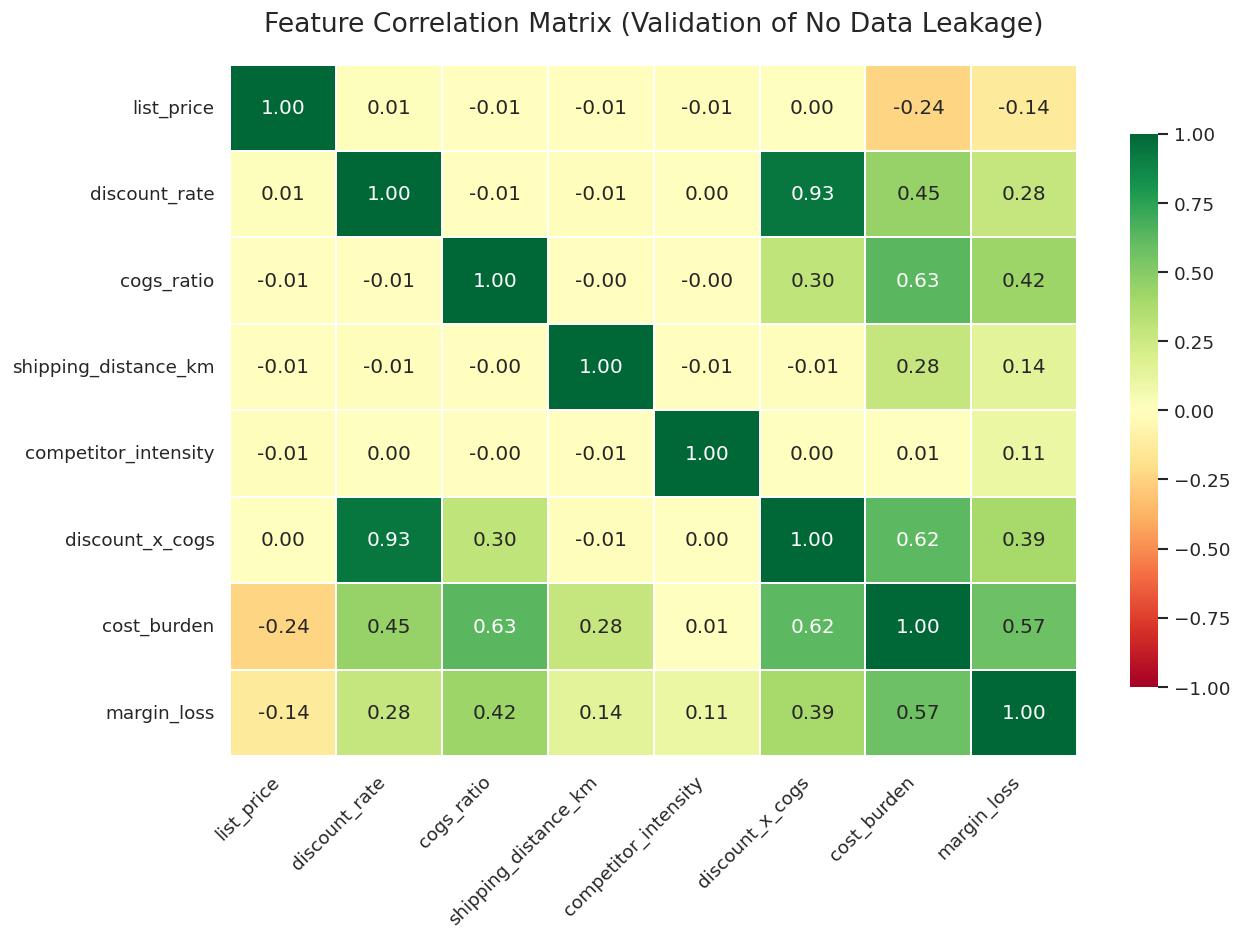

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette("husl")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

ml_features = [
    'list_price', 'discount_rate', 'cogs_ratio', 'shipping_distance_km',
    'competitor_intensity', 'discount_x_cogs', 'cost_burden', 'margin_loss'
]

corr_matrix = df[ml_features].corr()

plt.figure(figsize=(11, 8))

# REMOVED THE MASK HERE
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f",
            linewidths=1, vmin=-1, vmax=1, cbar_kws={"shrink": .8})

plt.title('Feature Correlation Matrix (Validation of No Data Leakage)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

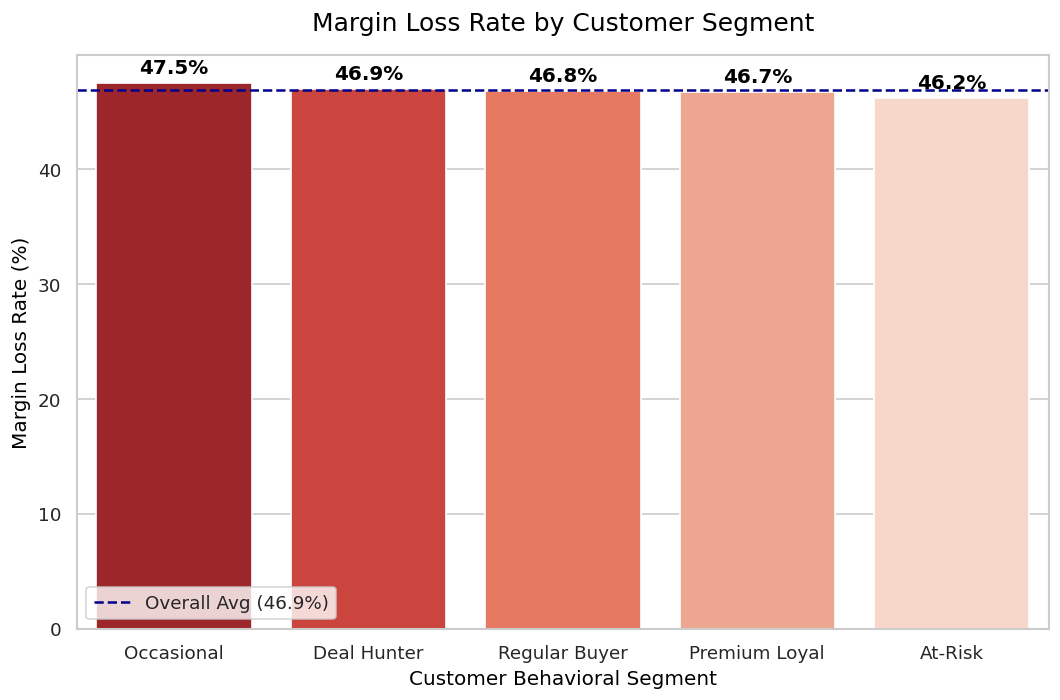

In [ ]:
segment_loss = df.groupby('segment')['margin_loss'].mean() * 100
segment_loss = segment_loss.sort_values(ascending=False)

plt.figure(figsize=(9, 6))
# Changed to a standard barplot without the grid blocking it
bars = sns.barplot(x=segment_loss.index, y=segment_loss.values, palette='Reds_r')

overall_avg = df['margin_loss'].mean() * 100
# Changed line color to dark blue for visibility
plt.axhline(y=overall_avg, color='darkblue', linestyle='--', label=f'Overall Avg ({overall_avg:.1f}%)')

plt.title('Margin Loss Rate by Customer Segment', fontsize=15, pad=15, color='black')
plt.ylabel('Margin Loss Rate (%)', fontsize=12, color='black')
plt.xlabel('Customer Behavioral Segment', fontsize=12, color='black')

for bar in bars.patches:
    # Changed text color to black for readability against lighter bars
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', color='black', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

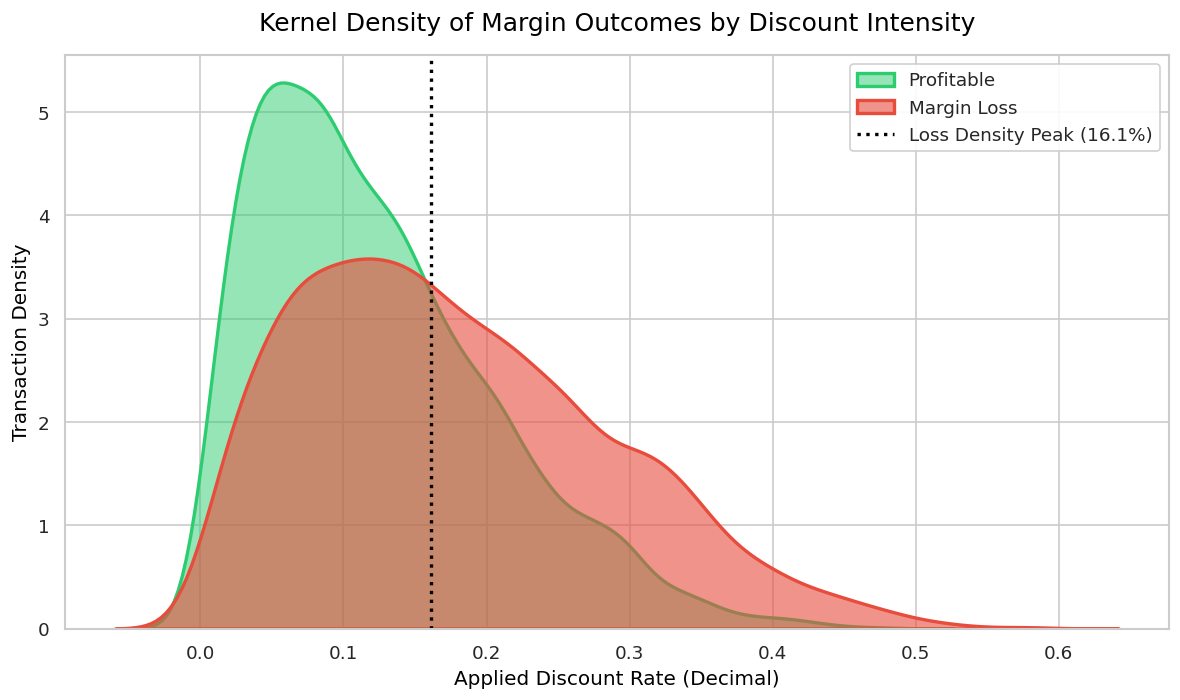

In [ ]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df[df['margin_loss'] == 0], x='discount_rate', fill=True,
            color='#2ecc71', label='Profitable', alpha=0.5, linewidth=2)
sns.kdeplot(data=df[df['margin_loss'] == 1], x='discount_rate', fill=True,
            color='#e74c3c', label='Margin Loss', alpha=0.6, linewidth=2)

median_loss_discount = df[df['margin_loss'] == 1]['discount_rate'].median()
# Changed the threshold line to black
plt.axvline(x=median_loss_discount, color='black', linestyle=':', linewidth=2,
            label=f'Loss Density Peak ({median_loss_discount*100:.1f}%)')

plt.title('Kernel Density of Margin Outcomes by Discount Intensity', fontsize=15, pad=15, color='black')
plt.xlabel('Applied Discount Rate (Decimal)', fontsize=12, color='black')
plt.ylabel('Transaction Density', fontsize=12, color='black')
plt.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()

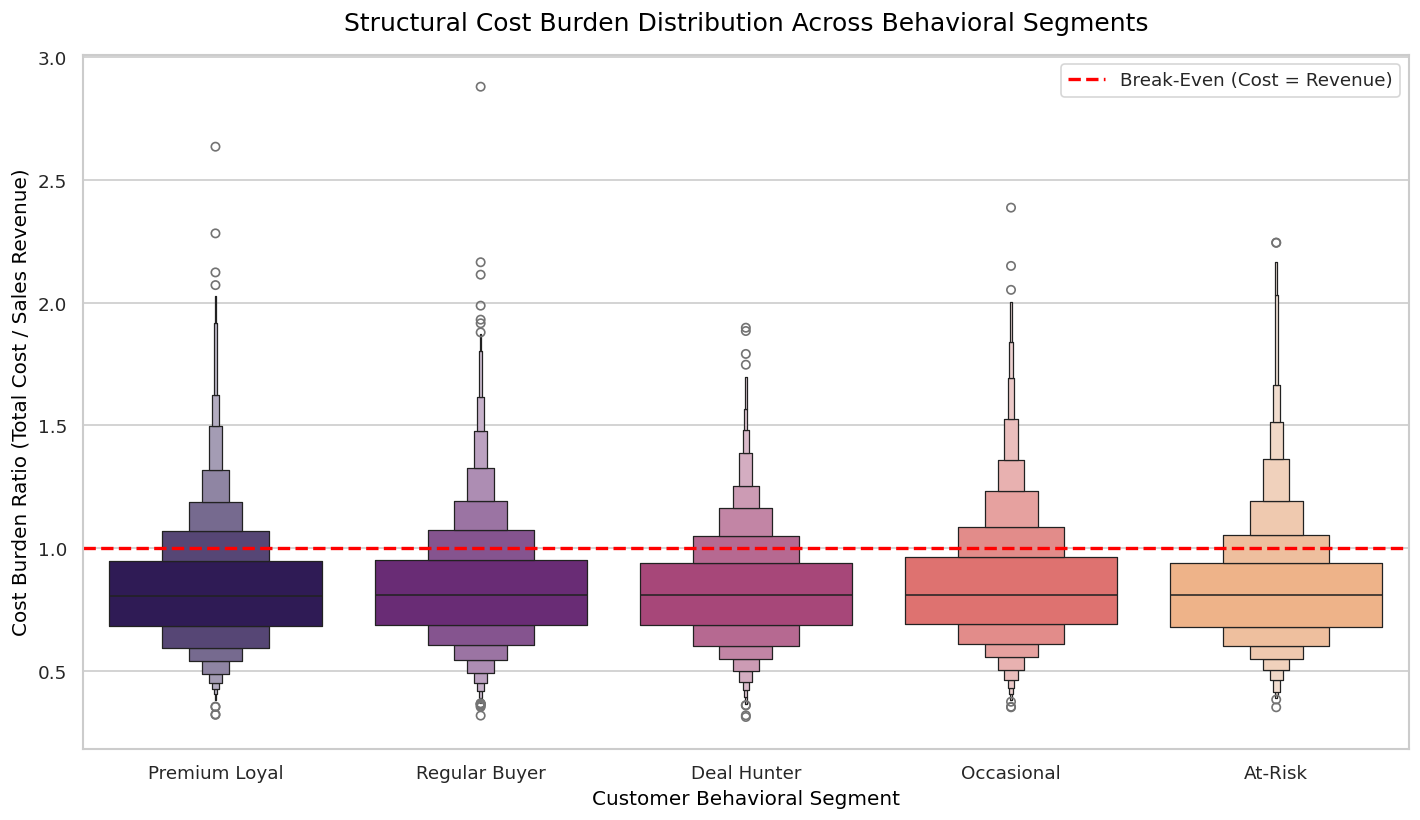

In [ ]:
plt.figure(figsize=(12, 7))

order = df.groupby('segment')['cost_burden'].median().sort_values().index

sns.boxenplot(data=df, x='segment', y='cost_burden', order=order,
              palette='magma', k_depth='proportion')

# Kept line red for emphasis against the white background
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Break-Even (Cost = Revenue)')

plt.title('Structural Cost Burden Distribution Across Behavioral Segments', fontsize=15, pad=15, color='black')
plt.xlabel('Customer Behavioral Segment', fontsize=12, color='black')
plt.ylabel('Cost Burden Ratio (Total Cost / Sales Revenue)', fontsize=12, color='black')
plt.legend()
plt.tight_layout()
plt.show()

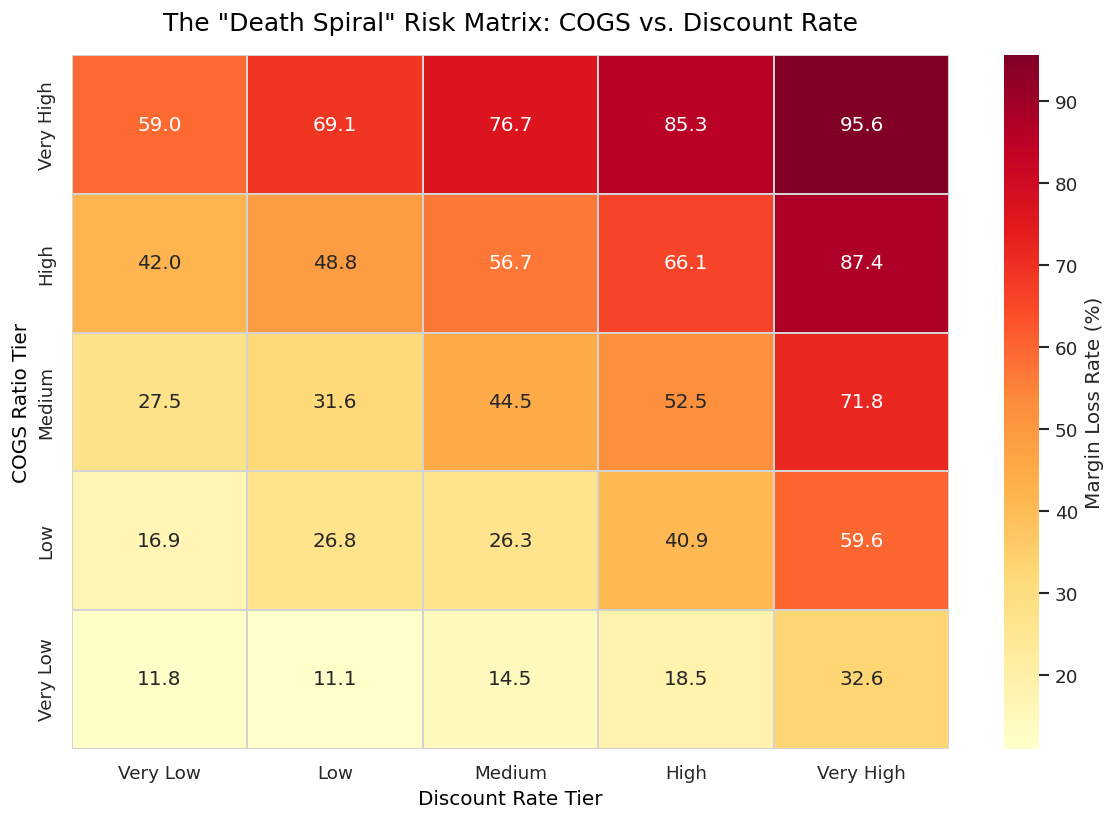

In [ ]:
df['cogs_tier'] = pd.qcut(df['cogs_ratio'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
df['discount_tier'] = pd.qcut(df['discount_rate'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

risk_matrix = df.groupby(['cogs_tier', 'discount_tier'], observed=False)['margin_loss'].mean().unstack() * 100

plt.figure(figsize=(10, 7))
sns.heatmap(risk_matrix, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Margin Loss Rate (%)'}, linewidths=1, linecolor='lightgray')

plt.title('The "Death Spiral" Risk Matrix: COGS vs. Discount Rate', fontsize=15, pad=15, color='black')
plt.xlabel('Discount Rate Tier', fontsize=12, color='black')
plt.ylabel('COGS Ratio Tier', fontsize=12, color='black')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

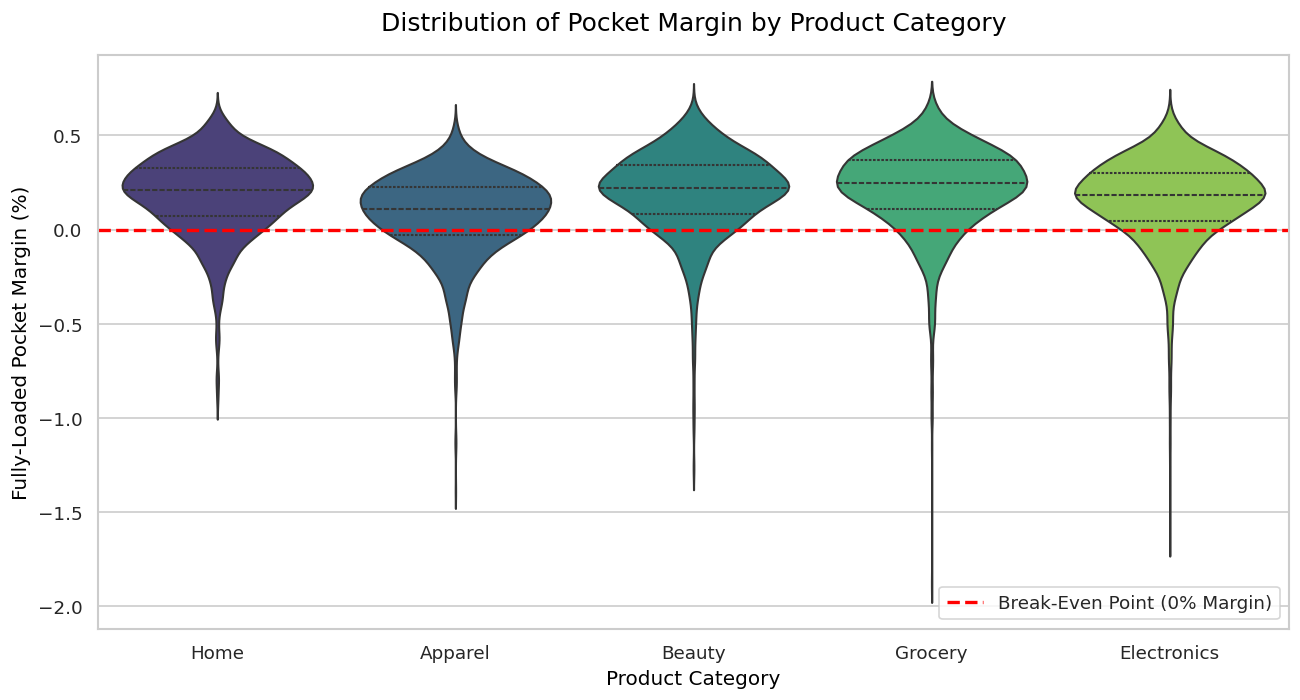

In [ ]:
plt.figure(figsize=(11, 6))

sns.violinplot(data=df, x='category', y='pocket_margin_pct', palette='viridis', inner='quartile')

plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Break-Even Point (0% Margin)')

plt.title('Distribution of Pocket Margin by Product Category', fontsize=15, pad=15, color='black')
plt.xlabel('Product Category', fontsize=12, color='black')
plt.ylabel('Fully-Loaded Pocket Margin (%)', fontsize=12, color='black')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

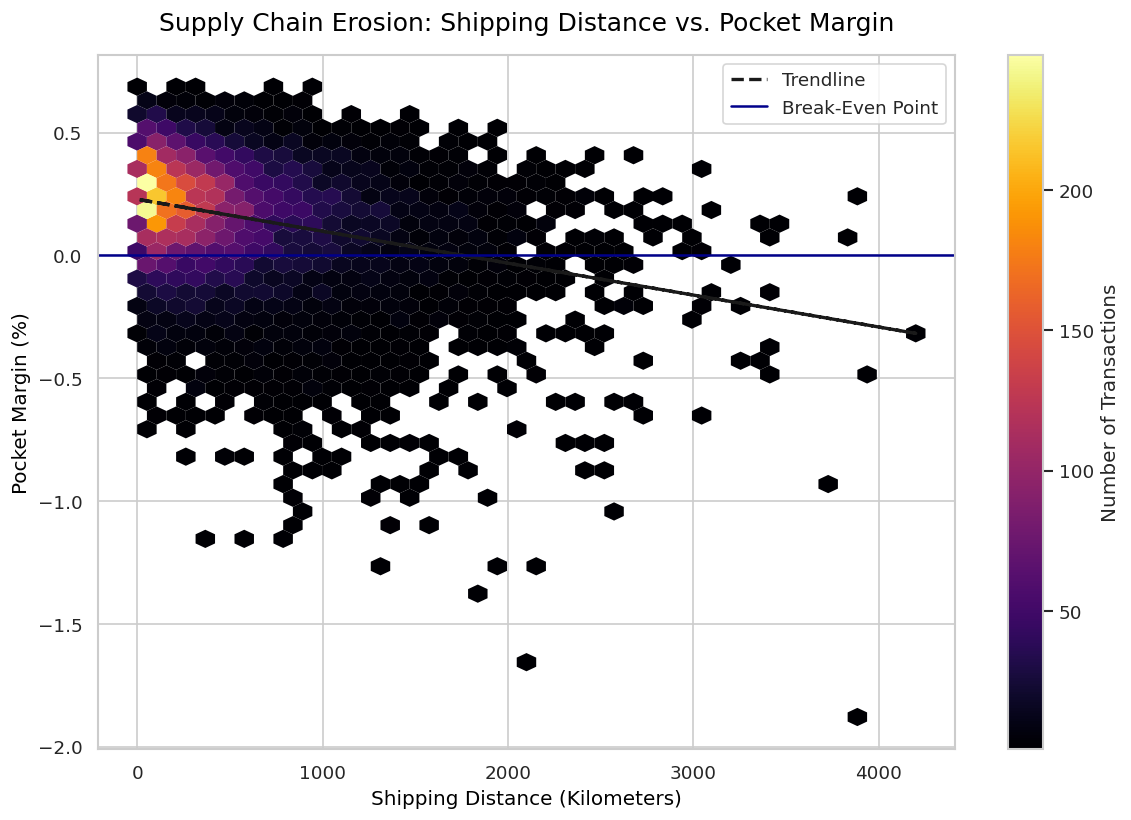

In [ ]:
plt.figure(figsize=(10, 7))

# Added an edge color to the hexbins so they don't bleed into the white background
hb = plt.hexbin(df['shipping_distance_km'], df['pocket_margin_pct'],
                gridsize=40, cmap='inferno', mincnt=1, edgecolors='none')

z = np.polyfit(df['shipping_distance_km'], df['pocket_margin_pct'], 1)
p = np.poly1d(z)
# Changed trendline to black dashed ("k--")
plt.plot(df['shipping_distance_km'], p(df['shipping_distance_km']), "k--", linewidth=2, label=f'Trendline')

# Changed break-even line to a dark blue
plt.axhline(y=0, color='darkblue', linestyle='-', linewidth=1.5, label='Break-Even Point')

cb = plt.colorbar(hb, label='Number of Transactions')
plt.title('Supply Chain Erosion: Shipping Distance vs. Pocket Margin', fontsize=15, pad=15, color='black')
plt.xlabel('Shipping Distance (Kilometers)', fontsize=12, color='black')
plt.ylabel('Pocket Margin (%)', fontsize=12, color='black')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

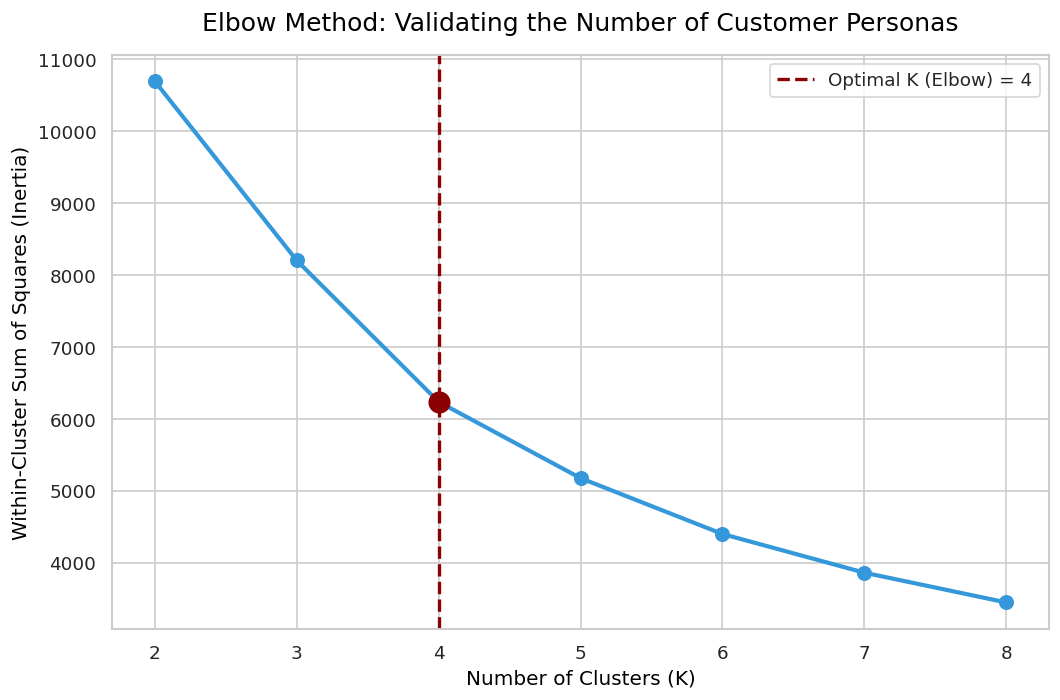

In [ ]:
# PHASE 3 | BLOCK 1: MATHEMATICAL JUSTIFICATION (ELBOW METHOD)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Prepare data for clustering
cluster_features = df[['discount_rate', 'cost_burden']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

# 2. Calculate Inertia for different K values
inertia = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# 3. Visualize the Elbow
plt.figure(figsize=(9, 6))
plt.plot(K_range, inertia, marker='o', markersize=8, color='#3498db', linewidth=2.5)

plt.axvline(x=4, color='darkred', linestyle='--', linewidth=2, label='Optimal K (Elbow) = 4')
plt.scatter(4, inertia[2], color='darkred', s=150, zorder=5)

plt.title('Elbow Method: Validating the Number of Customer Personas', fontsize=15, color='black', pad=15)
plt.xlabel('Number of Clusters (K)', fontsize=12, color='black')
plt.ylabel('Within-Cluster Sum of Squares (Inertia)', fontsize=12, color='black')
plt.legend()
plt.tight_layout()
plt.show()

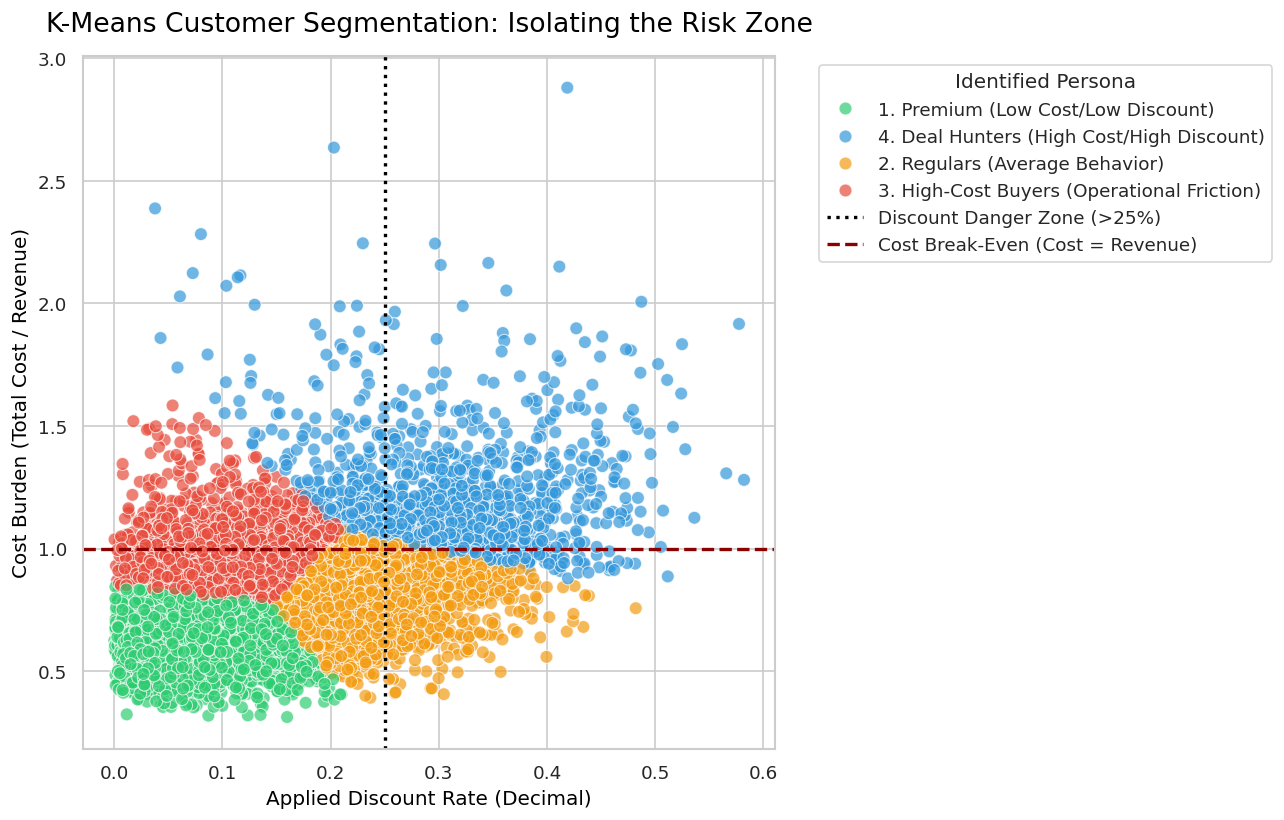

In [ ]:
# PHASE 3 | BLOCK 2: DIAGNOSTIC CLUSTERING - BEHAVIORAL PERSONAS
# 1. Apply K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster_id'] = kmeans.fit_predict(X_scaled)

# 2. Dynamically name clusters based on their mathematical centers
cluster_centers = df.groupby('cluster_id')[['discount_rate', 'cost_burden']].mean()
cluster_centers['risk_score'] = cluster_centers['discount_rate'] + cluster_centers['cost_burden']
cluster_centers = cluster_centers.sort_values('risk_score')

# Map the sorted indices to business names (Lowest risk to Highest risk)
name_mapping = {
    cluster_centers.index[0]: '1. Premium (Low Cost/Low Discount)',
    cluster_centers.index[1]: '2. Regulars (Average Behavior)',
    cluster_centers.index[2]: '3. High-Cost Buyers (Operational Friction)',
    cluster_centers.index[3]: '4. Deal Hunters (High Cost/High Discount)'
}
df['persona'] = df['cluster_id'].map(name_mapping)

# 3. Visualize the Clusters
plt.figure(figsize=(11, 7))
sns.scatterplot(data=df, x='discount_rate', y='cost_burden', hue='persona',
                palette=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'], alpha=0.7, s=60, edgecolor='white')

# Add the break-even risk lines
plt.axvline(x=0.25, color='black', linestyle=':', linewidth=2, label='Discount Danger Zone (>25%)')
plt.axhline(y=1.0, color='darkred', linestyle='--', linewidth=2, label='Cost Break-Even (Cost = Revenue)')

plt.title('K-Means Customer Segmentation: Isolating the Risk Zone', fontsize=16, color='black', pad=15)
plt.xlabel('Applied Discount Rate (Decimal)', fontsize=12, color='black')
plt.ylabel('Cost Burden (Total Cost / Revenue)', fontsize=12, color='black')
plt.legend(title='Identified Persona', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

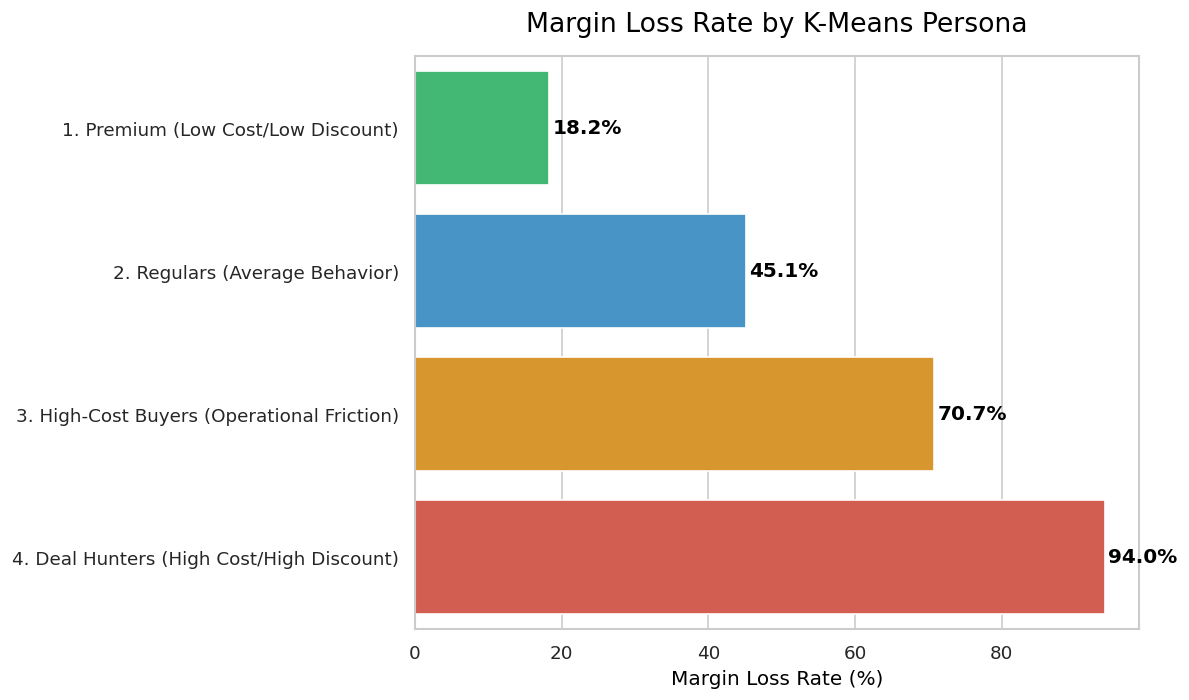

In [ ]:
# PHASE 3 | BLOCK 3: CLUSTER FINANCIAL HEALTH
cluster_loss = df.groupby('persona')['margin_loss'].mean() * 100

plt.figure(figsize=(10, 6))
bars = sns.barplot(x=cluster_loss.values, y=cluster_loss.index, palette=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'])

plt.title('Margin Loss Rate by K-Means Persona', fontsize=16, color='black', pad=15)
plt.xlabel('Margin Loss Rate (%)', fontsize=12, color='black')
plt.ylabel('', fontsize=12)

# Add data labels
for i, bar in enumerate(bars.patches):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.1f}%', va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

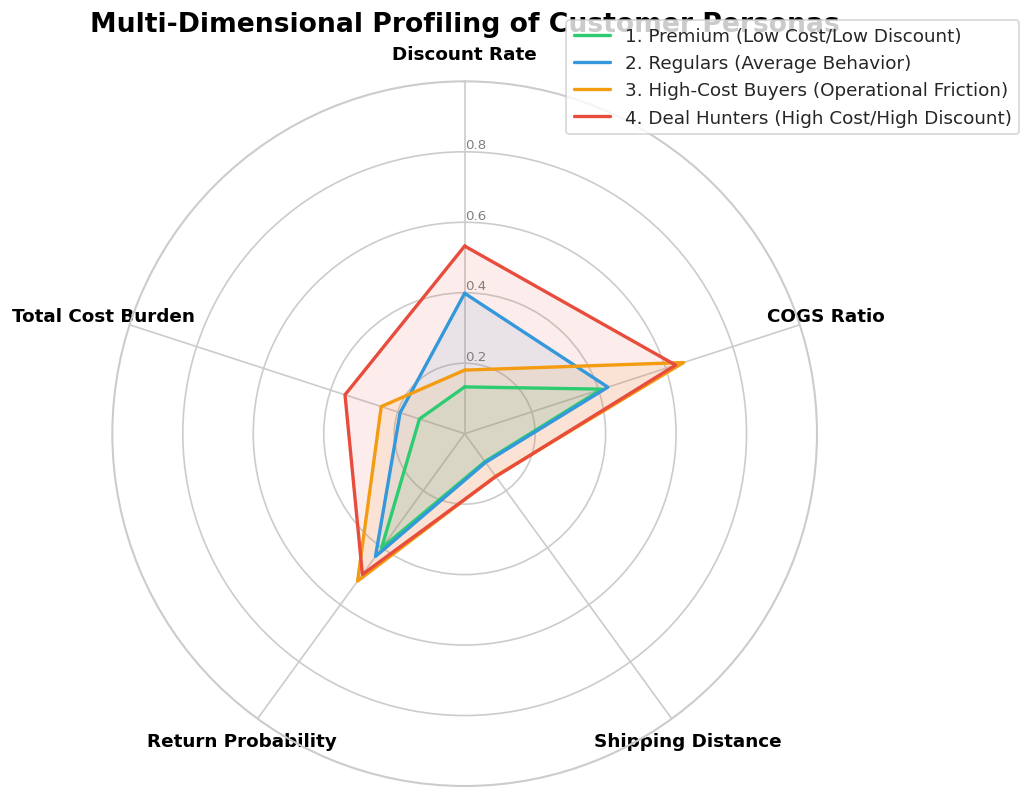

In [ ]:
# PHASE 3 | BLOCK 4: MULTI-DIMENSIONAL PERSONA PROFILING (RADAR CHART)
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. Select features to profile and normalize them (0 to 1 scale)
profile_features = ['discount_rate', 'cogs_ratio', 'shipping_distance_km', 'return_probability', 'cost_burden']
scaler_radar = MinMaxScaler()
df_radar_scaled = pd.DataFrame(scaler_radar.fit_transform(df[profile_features]), columns=profile_features)
df_radar_scaled['persona'] = df['persona']

# 2. Calculate the mean of each feature for each persona
cluster_means = df_radar_scaled.groupby('persona').mean()

# 3. Setup the Radar Chart
categories = ['Discount Rate', 'COGS Ratio', 'Shipping Distance', 'Return Probability', 'Total Cost Burden']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(9, 9))
ax = plt.subplot(111, polar=True)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], categories, color='black', size=11, fontweight='bold')
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color="grey", size=8)
plt.ylim(0, 1)

colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

# 4. Plot each persona
for idx, (persona_name, row) in enumerate(cluster_means.iterrows()):
    values = row.values.flatten().tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, linestyle='solid', label=persona_name, color=colors[idx])
    ax.fill(angles, values, alpha=0.1, color=colors[idx])

plt.title('Multi-Dimensional Profiling of Customer Personas', fontsize=16, color='black', pad=30, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

In [ ]:
# PHASE 4 | BLOCK 12: ML DATA PREP & SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd

ml_features = ['list_price', 'discount_rate', 'cogs_ratio', 'shipping_distance_km',
               'competitor_intensity', 'discount_x_cogs', 'cost_burden']
X = df[ml_features]
y = df['margin_loss']

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE Balancing
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Convert back to DataFrames to preserve column names for the Stats table
X_train_smote_df = pd.DataFrame(X_train_smote, columns=ml_features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=ml_features)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=ml_features) # For cost-sensitive model

In [ ]:
# PHASE 4 | BLOCK 13: STATISTICAL SIGNIFICANCE (P-VALUES)
import statsmodels.api as sm
import pandas as pd

# 1. Fit the statistical Logit model
X_train_sm_with_const = sm.add_constant(X_train_smote_df)
logit_model = sm.Logit(y_train_smote, X_train_sm_with_const)
stats_result = logit_model.fit(disp=0)

# 2. Extract Coefficients and P-Values into a clean DataFrame
p_values = stats_result.pvalues
coefficients = stats_result.params

sig_table = pd.DataFrame({
    'Feature': p_values.index,
    'Coefficient (Impact)': coefficients.values,
    'P-Value': p_values.values
})

# 3. Add a column to flag if it is statistically significant (P < 0.05)
sig_table['Significant?'] = sig_table['P-Value'].apply(lambda x: 'Yes (Strong)' if x < 0.05 else 'No')

# 4. Sort by the absolute impact
sig_table['Abs_Impact'] = sig_table['Coefficient (Impact)'].abs()
sig_table = sig_table.sort_values(by='Abs_Impact', ascending=False).drop(columns=['Abs_Impact'])

print("--- STATISTICAL SIGNIFICANCE TABLE (BASELINE REGRESSION) ---")
print(sig_table.to_string(index=False))

--- STATISTICAL SIGNIFICANCE TABLE (BASELINE REGRESSION) ---
             Feature  Coefficient (Impact)       P-Value Significant?
         cost_burden              2.176290 1.048822e-132 Yes (Strong)
     discount_x_cogs              0.338914  7.070802e-02           No
competitor_intensity              0.321742  5.291202e-30 Yes (Strong)
       discount_rate             -0.254919  1.376953e-01           No
               const              0.106425  4.176860e-04 Yes (Strong)
shipping_distance_km             -0.019363  5.651566e-01           No
          list_price             -0.012073  7.122354e-01           No
          cogs_ratio             -0.003919  9.568069e-01           No


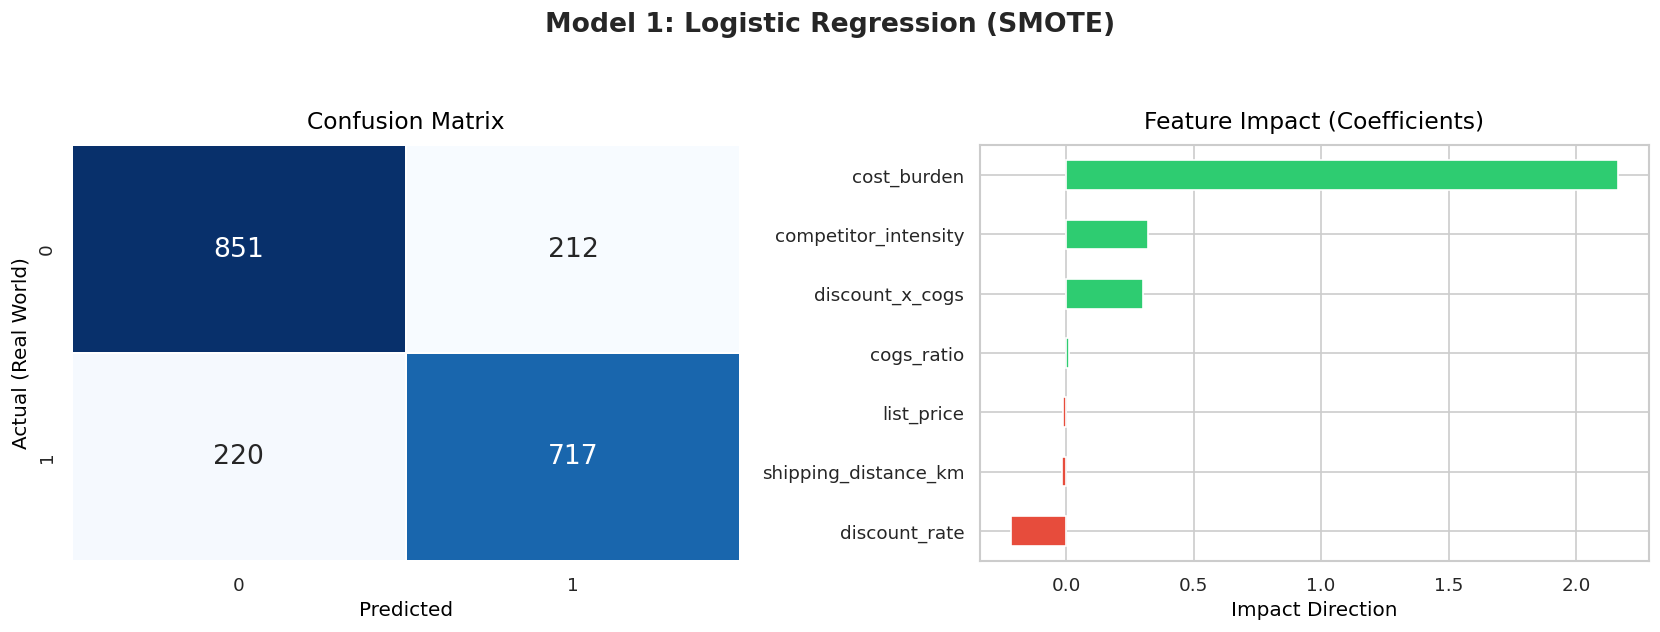

In [ ]:
# PHASE 4 | BLOCK 14: MODEL 1 - LR (SMOTE) WITH FEATURE IMPACT
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# Train
lr_smote = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=2000, random_state=42)
lr_smote.fit(X_train_smote_df, y_train_smote)
y_pred_lr = lr_smote.predict(X_test_scaled_df)

# Setup 1x2 Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues',
            cbar=False, annot_kws={"size": 16}, linewidths=1, linecolor='white', ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14, color='black', pad=10)
axes[0].set_ylabel('Actual (Real World)', fontsize=12, color='black')
axes[0].set_xlabel('Predicted', fontsize=12, color='black')

# Plot 2: Feature Impact (Coefficients)
coefs = pd.Series(lr_smote.coef_[0], index=ml_features).sort_values()
coefs.plot(kind='barh', ax=axes[1], color=['#e74c3c' if c < 0 else '#2ecc71' for c in coefs])
axes[1].set_title('Feature Impact (Coefficients)', fontsize=14, color='black', pad=10)
axes[1].set_xlabel('Impact Direction', fontsize=12, color='black')

plt.suptitle('Model 1: Logistic Regression (SMOTE)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

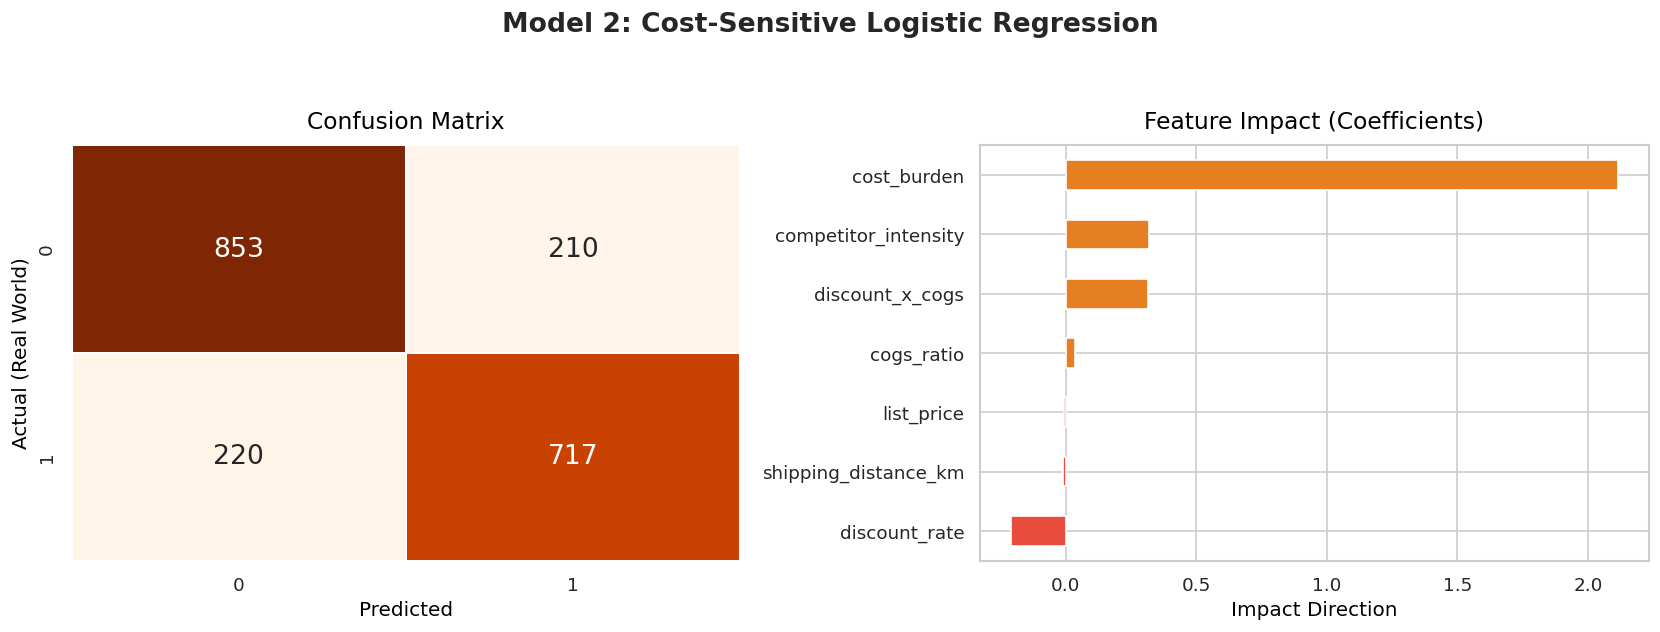

In [ ]:
# PHASE 4 | BLOCK 15: MODEL 2 - COST-SENSITIVE LR WITH FEATURE IMPACT
# Train
lr_cost = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
lr_cost.fit(X_train_scaled_df, y_train)
y_pred_lrc = lr_cost.predict(X_test_scaled_df)

# Setup 1x2 Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lrc), annot=True, fmt='d', cmap='Oranges',
            cbar=False, annot_kws={"size": 16}, linewidths=1, linecolor='white', ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14, color='black', pad=10)
axes[0].set_ylabel('Actual (Real World)', fontsize=12, color='black')
axes[0].set_xlabel('Predicted', fontsize=12, color='black')

# Plot 2: Feature Impact (Coefficients)
coefs_cost = pd.Series(lr_cost.coef_[0], index=ml_features).sort_values()
coefs_cost.plot(kind='barh', ax=axes[1], color=['#e74c3c' if c < 0 else '#e67e22' for c in coefs_cost])
axes[1].set_title('Feature Impact (Coefficients)', fontsize=14, color='black', pad=10)
axes[1].set_xlabel('Impact Direction', fontsize=12, color='black')

plt.suptitle('Model 2: Cost-Sensitive Logistic Regression', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

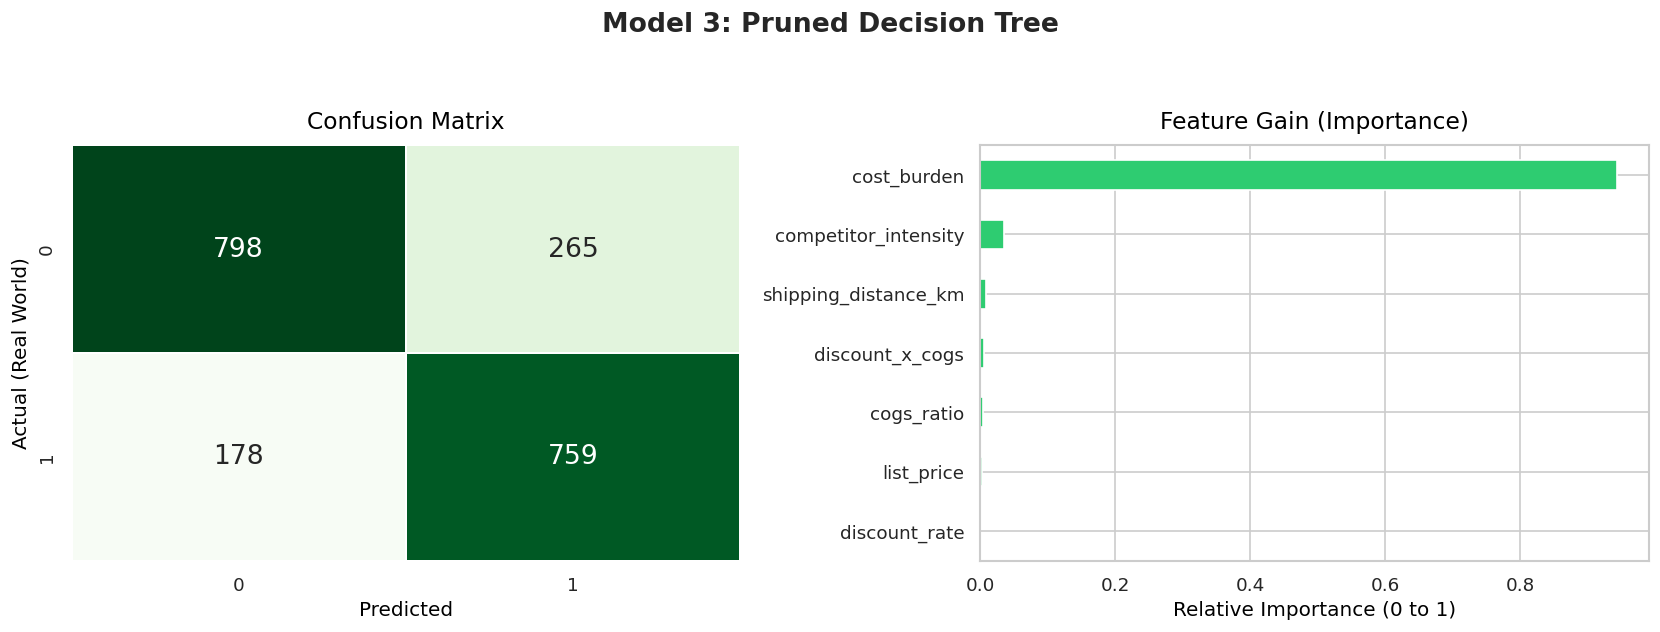

In [ ]:
# PHASE 4 | BLOCK 16: MODEL 3 - DECISION TREE WITH FEATURE GAIN
from sklearn.tree import DecisionTreeClassifier

# Train
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_model.fit(X_train_scaled_df, y_train)
y_pred_dt = dt_model.predict(X_test_scaled_df)

# Setup 1x2 Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Greens',
            cbar=False, annot_kws={"size": 16}, linewidths=1, linecolor='white', ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14, color='black', pad=10)
axes[0].set_ylabel('Actual (Real World)', fontsize=12, color='black')
axes[0].set_xlabel('Predicted', fontsize=12, color='black')

# Plot 2: Feature Gain (Importance)
importances_dt = pd.Series(dt_model.feature_importances_, index=ml_features).sort_values()
importances_dt.plot(kind='barh', ax=axes[1], color='#2ecc71')
axes[1].set_title('Feature Gain (Importance)', fontsize=14, color='black', pad=10)
axes[1].set_xlabel('Relative Importance (0 to 1)', fontsize=12, color='black')

plt.suptitle('Model 3: Pruned Decision Tree', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

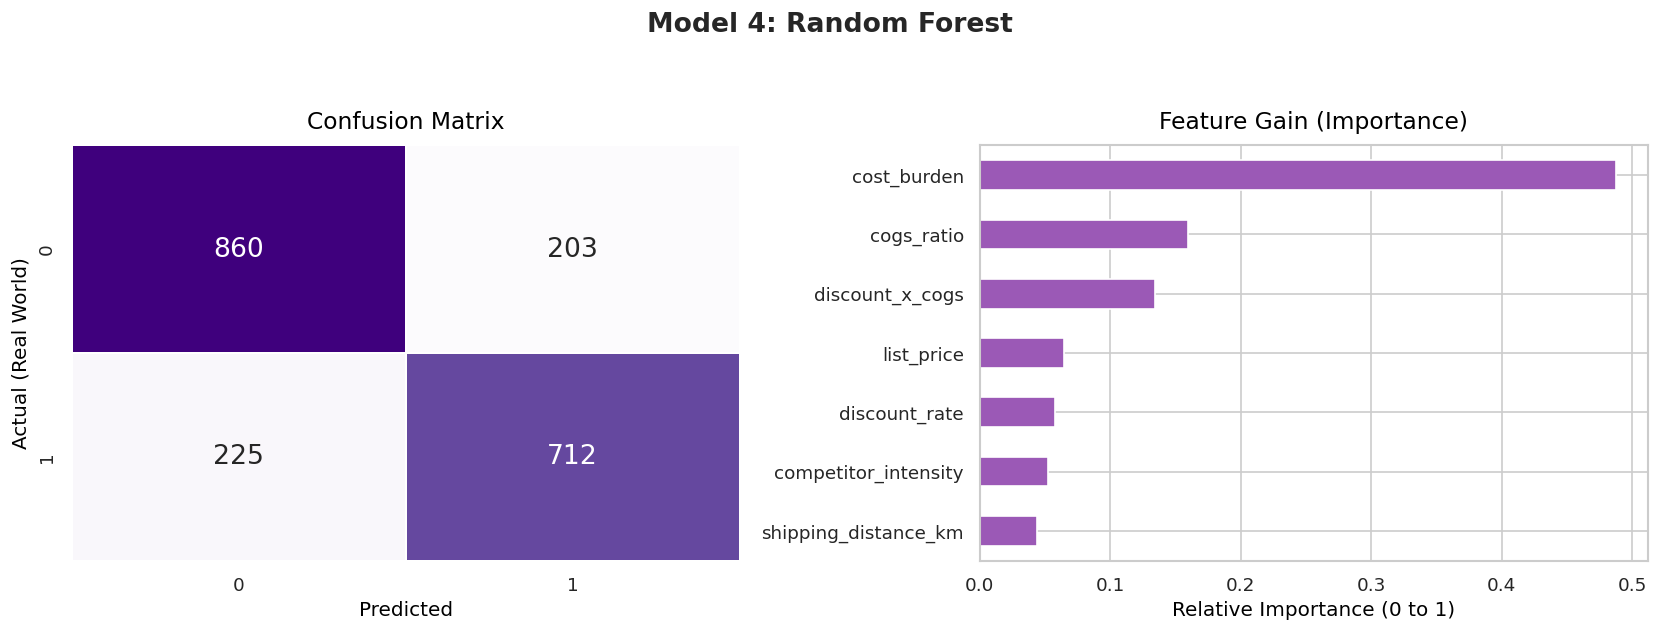

In [ ]:
# PHASE 4 | BLOCK 17: MODEL 4 - RANDOM FOREST WITH FEATURE GAIN
from sklearn.ensemble import RandomForestClassifier

# Train
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled_df, y_train)
y_pred_rf = rf_model.predict(X_test_scaled_df)

# Setup 1x2 Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Purples',
            cbar=False, annot_kws={"size": 16}, linewidths=1, linecolor='white', ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14, color='black', pad=10)
axes[0].set_ylabel('Actual (Real World)', fontsize=12, color='black')
axes[0].set_xlabel('Predicted', fontsize=12, color='black')

# Plot 2: Feature Gain (Importance)
importances_rf = pd.Series(rf_model.feature_importances_, index=ml_features).sort_values()
importances_rf.plot(kind='barh', ax=axes[1], color='#9b59b6')
axes[1].set_title('Feature Gain (Importance)', fontsize=14, color='black', pad=10)
axes[1].set_xlabel('Relative Importance (0 to 1)', fontsize=12, color='black')

plt.suptitle('Model 4: Random Forest', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

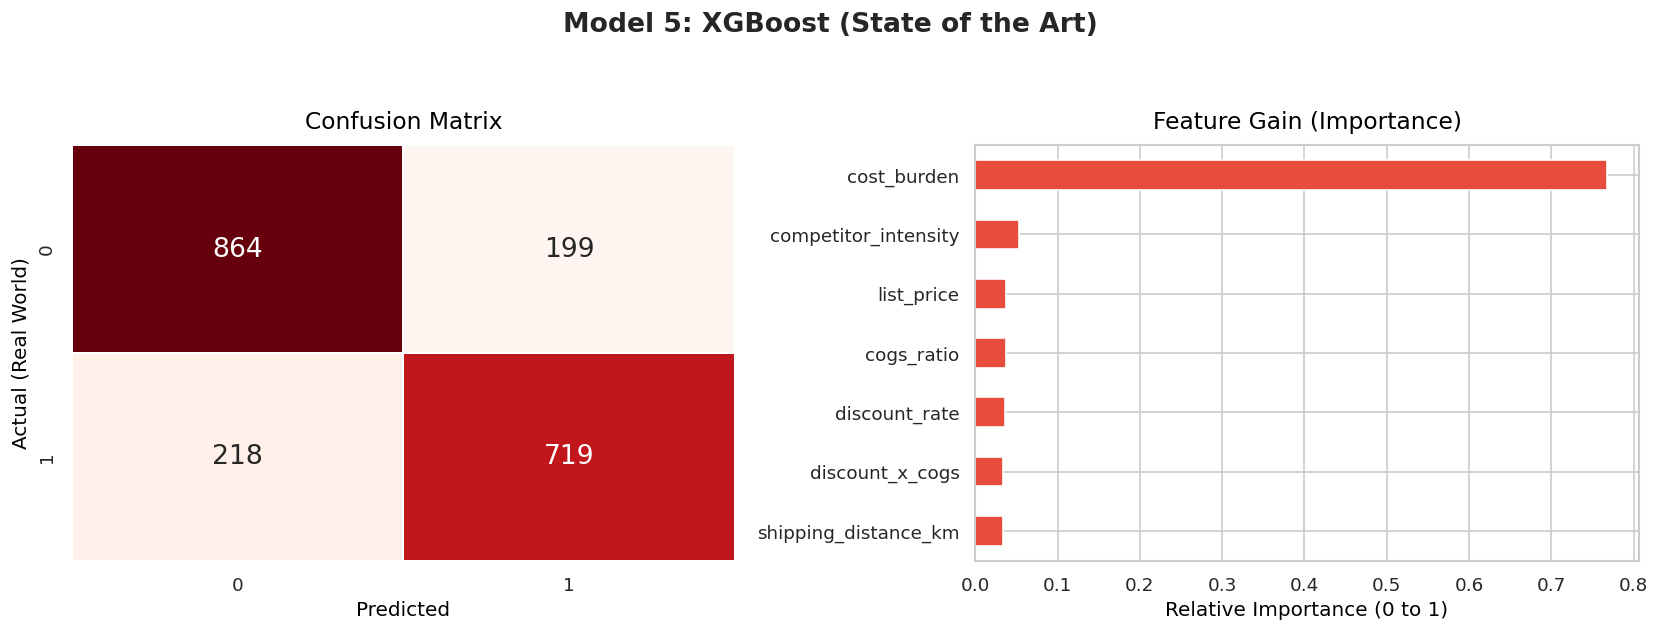

In [ ]:
# PHASE 4 | BLOCK 18: MODEL 5 - XGBOOST WITH FEATURE GAIN
import xgboost as xgb

pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# Train
xgb_model = xgb.XGBClassifier(scale_pos_weight=pos_weight, max_depth=5, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train_scaled_df, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled_df)

# Setup 1x2 Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Reds',
            cbar=False, annot_kws={"size": 16}, linewidths=1, linecolor='white', ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14, color='black', pad=10)
axes[0].set_ylabel('Actual (Real World)', fontsize=12, color='black')
axes[0].set_xlabel('Predicted', fontsize=12, color='black')

# Plot 2: Feature Gain (Importance)
importances_xgb = pd.Series(xgb_model.feature_importances_, index=ml_features).sort_values()
importances_xgb.plot(kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Feature Gain (Importance)', fontsize=14, color='black', pad=10)
axes[1].set_xlabel('Relative Importance (0 to 1)', fontsize=12, color='black')

plt.suptitle('Model 5: XGBoost (State of the Art)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

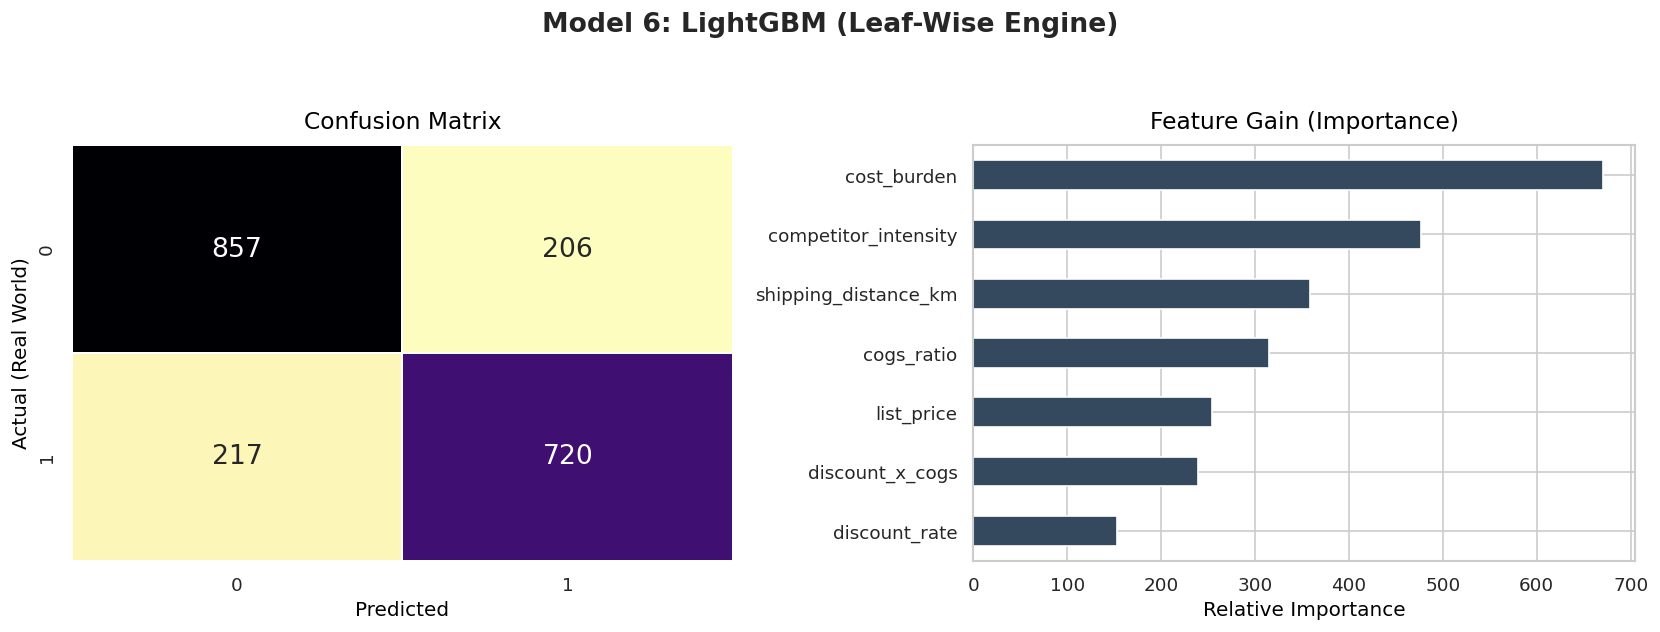

In [ ]:
# PHASE 4 | BLOCK 19: MODEL 6 - LIGHTGBM WITH FEATURE GAIN
import lightgbm as lgb

# Train
lgb_model = lgb.LGBMClassifier(is_unbalance=True, max_depth=5, learning_rate=0.05, random_state=42, verbose=-1)
lgb_model.fit(X_train_scaled_df, y_train)
y_pred_lgb = lgb_model.predict(X_test_scaled_df)

# Setup 1x2 Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lgb), annot=True, fmt='d', cmap='magma_r',
            cbar=False, annot_kws={"size": 16}, linewidths=1, linecolor='white', ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14, color='black', pad=10)
axes[0].set_ylabel('Actual (Real World)', fontsize=12, color='black')
axes[0].set_xlabel('Predicted', fontsize=12, color='black')

# Plot 2: Feature Gain (Importance)
importances_lgb = pd.Series(lgb_model.feature_importances_, index=ml_features).sort_values()
importances_lgb.plot(kind='barh', ax=axes[1], color='#34495e')
axes[1].set_title('Feature Gain (Importance)', fontsize=14, color='black', pad=10)
axes[1].set_xlabel('Relative Importance', fontsize=12, color='black')

plt.suptitle('Model 6: LightGBM (Leaf-Wise Engine)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


 MASTER MODEL EVALUATION TABLE (RANKED BY F1-SCORE)
                  Model  Accuracy  Recall (Catch Leaks)  Precision (True Alarm)  F1-Score
1            5. XGBoost     0.791                 0.767                   0.783     0.775
2      3. Decision Tree     0.778                 0.810                   0.741     0.774
3           6. LightGBM     0.788                 0.768                   0.778     0.773
4  2. Cost-Sensitive LR     0.785                 0.765                   0.773     0.769
5      4. Random Forest     0.786                 0.760                   0.778     0.769
6         1. LR (SMOTE)     0.784                 0.765                   0.772     0.768



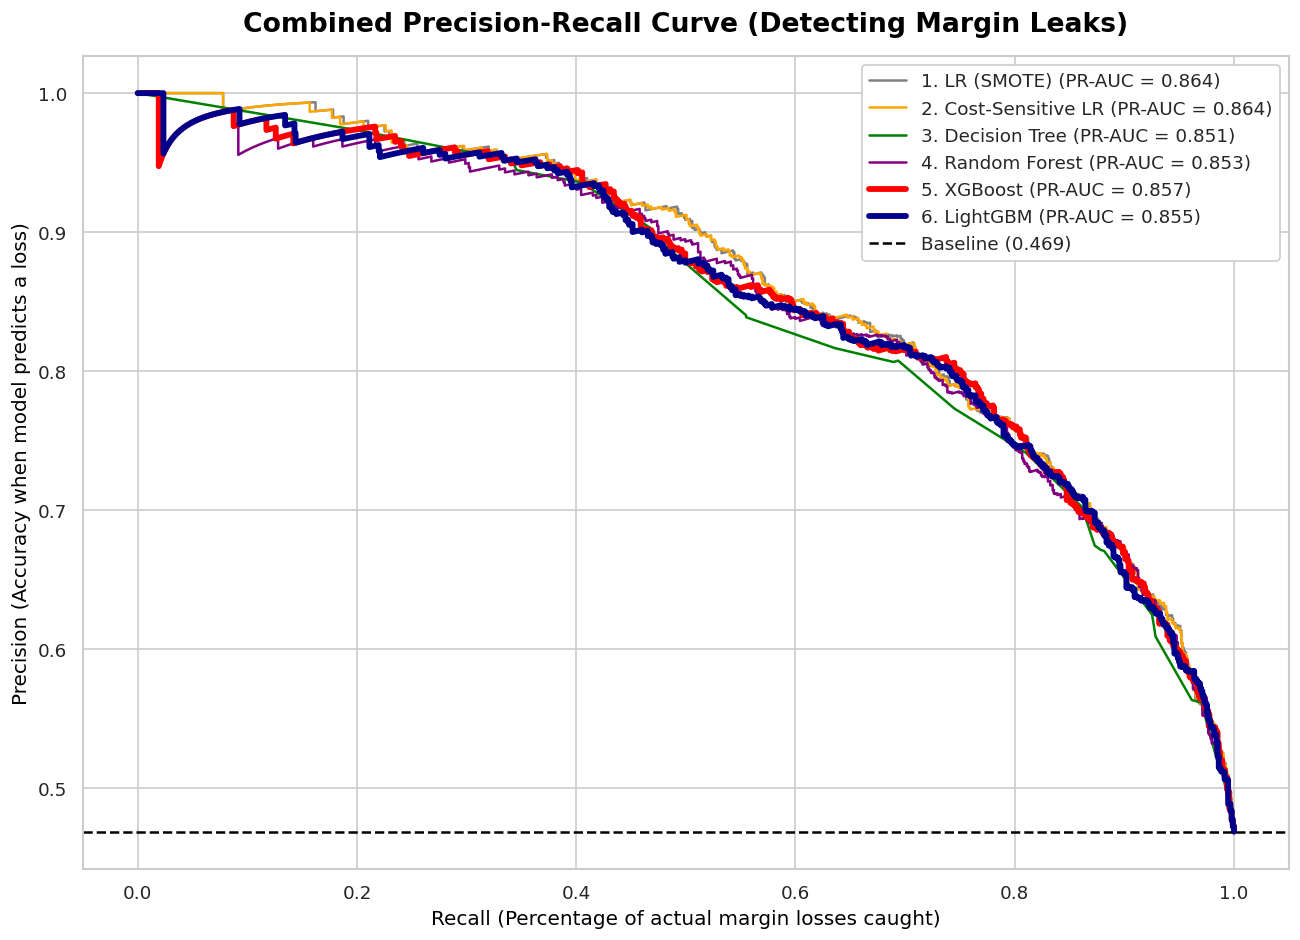

In [ ]:
# PHASE 4 | BLOCK 20: MASTER EVALUATION TABLE & PR-AUC CURVE
from sklearn.metrics import precision_recall_curve, auc, f1_score, recall_score, precision_score, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# 1. Gather all predictions and probabilities
probs = {
    '1. LR (SMOTE)': lr_smote.predict_proba(X_test_scaled_df)[:, 1],
    '2. Cost-Sensitive LR': lr_cost.predict_proba(X_test_scaled_df)[:, 1],
    '3. Decision Tree': dt_model.predict_proba(X_test_scaled_df)[:, 1],
    '4. Random Forest': rf_model.predict_proba(X_test_scaled_df)[:, 1],
    '5. XGBoost': xgb_model.predict_proba(X_test_scaled_df)[:, 1],
    '6. LightGBM': lgb_model.predict_proba(X_test_scaled_df)[:, 1]
}

preds = {
    '1. LR (SMOTE)': y_pred_lr,
    '2. Cost-Sensitive LR': y_pred_lrc,
    '3. Decision Tree': y_pred_dt,
    '4. Random Forest': y_pred_rf,
    '5. XGBoost': y_pred_xgb,
    '6. LightGBM': y_pred_lgb
}

# 2. Generate the Master Ranked Performance Table
metrics = []
for name, y_pred in preds.items():
    metrics.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 3),
        'Recall (Catch Leaks)': round(recall_score(y_test, y_pred), 3),
        'Precision (True Alarm)': round(precision_score(y_test, y_pred), 3),
        'F1-Score': round(f1_score(y_test, y_pred), 3)
    })

# Sort by F1-Score (Best overall balance for imbalanced data)
metrics_df = pd.DataFrame(metrics).sort_values(by='F1-Score', ascending=False)

# Reset index to create a clean ranking 1 through 6
metrics_df.reset_index(drop=True, inplace=True)
metrics_df.index = metrics_df.index + 1

print("\n" + "="*70)
print(" MASTER MODEL EVALUATION TABLE (RANKED BY F1-SCORE)")
print("="*70)
print(metrics_df.to_string())
print("="*70 + "\n")

# 3. Plot Combined PR-AUC Curve
plt.figure(figsize=(11, 8))
colors = ['gray', 'orange', 'green', 'purple', 'red', 'darkblue']

for (name, prob), color in zip(probs.items(), colors):
    p, r, _ = precision_recall_curve(y_test, prob)
    pr_auc = auc(r, p)
    # Emphasize the top tier models
    lw = 3.5 if 'XGBoost' in name or 'LightGBM' in name else 1.5
    plt.plot(r, p, label=f'{name} (PR-AUC = {pr_auc:.3f})', color=color, linewidth=lw)

# Plot Baseline
baseline = sum(y_test == 1) / len(y_test)
plt.axhline(y=baseline, color='black', linestyle='--', label=f'Baseline ({baseline:.3f})')

plt.title('Combined Precision-Recall Curve (Detecting Margin Leaks)', fontsize=16, color='black', pad=15, fontweight='bold')
plt.xlabel('Recall (Percentage of actual margin losses caught)', fontsize=12, color='black')
plt.ylabel('Precision (Accuracy when model predicts a loss)', fontsize=12, color='black')
plt.legend(loc='upper right', framealpha=1.0)
plt.tight_layout()
plt.show()

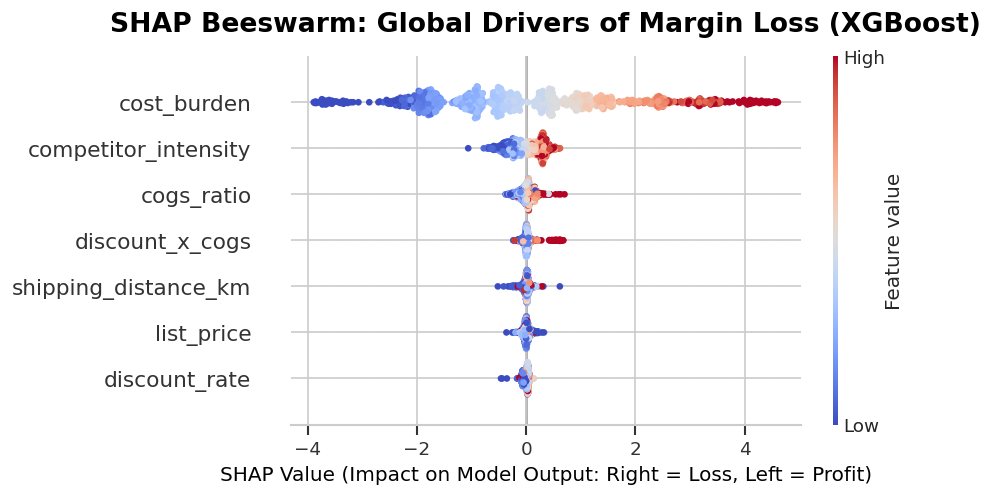

In [ ]:
# PHASE 5 | BLOCK 21: GLOBAL EXPLAINABILITY (SHAP BEESWARM)
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Tree Explainer with our best model (XGBoost)
# We use X_train_scaled_df because tree models don't strictly need SMOTE if scale_pos_weight is used
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values on a sample of the Test Set (for speed and visual clarity)
# Taking a representative sample of 1000 transactions
X_test_sample = X_test_scaled_df.sample(n=1000, random_state=42)
shap_values = explainer(X_test_sample)

# 2. Plot the Beeswarm
plt.figure(figsize=(10, 7))
# We map the feature names directly into the SHAP plot
shap.summary_plot(shap_values, X_test_sample, feature_names=ml_features, show=False, cmap='coolwarm')

plt.title('SHAP Beeswarm: Global Drivers of Margin Loss (XGBoost)', fontsize=16, color='black', pad=15, fontweight='bold')
plt.xlabel('SHAP Value (Impact on Model Output: Right = Loss, Left = Profit)', fontsize=12, color='black')
plt.tight_layout()
plt.show()

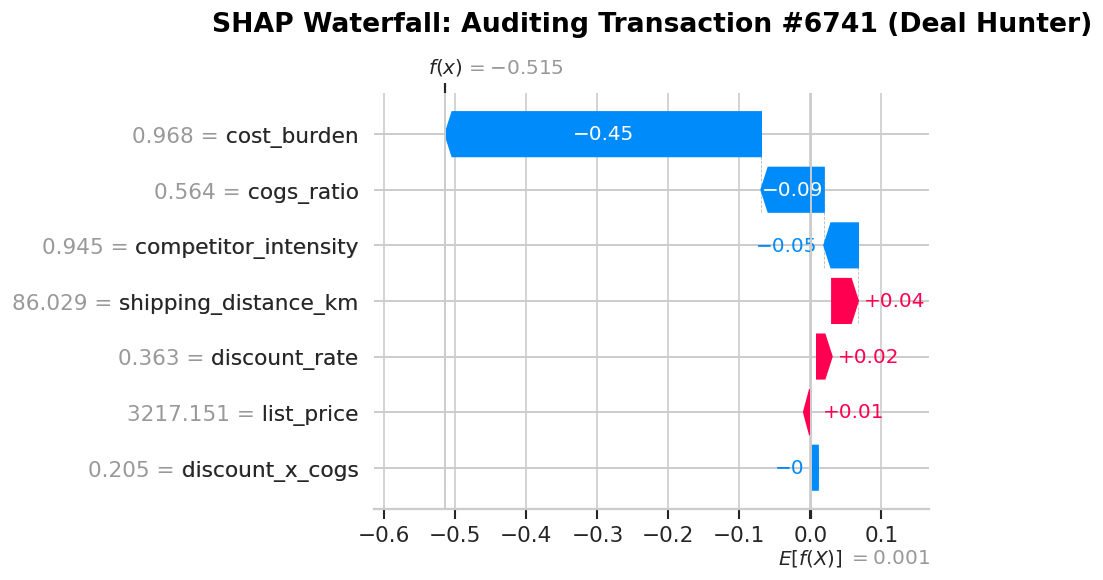

In [ ]:
# PHASE 5 | BLOCK 22: LOCAL EXPLAINABILITY (WATERFALL PLOT)
import numpy as np

# 1. Find a classic "Deal Hunter" transaction that was a True Positive (Model caught the leak)
# We merge the test features back with the cluster IDs we created in Phase 3
test_indices = X_test.index
df_test_full = df.loc[test_indices].copy()
df_test_full['predicted_loss'] = y_pred_xgb

# Filter for: Deal Hunter AND Actual Loss AND Predicted Loss
deal_hunter_leaks = df_test_full[(df_test_full['persona'].str.contains('Deal Hunter')) &
                                 (df_test_full['margin_loss'] == 1) &
                                 (df_test_full['predicted_loss'] == 1)]

# Pick the first transaction in this list to audit
audit_index = deal_hunter_leaks.index[0]

# Find the corresponding row in our scaled test dataset
scaled_index = np.where(X_test.index == audit_index)[0][0]

# 2. Generate the Waterfall Plot for this specific transaction
plt.figure(figsize=(10, 6))
# Create an Explanation object for just this one transaction
shap_exp = shap.Explanation(values=shap_values.values[scaled_index],
                            base_values=shap_values.base_values[scaled_index],
                            data=X_test.iloc[scaled_index].values, # Show actual raw numbers, not scaled!
                            feature_names=ml_features)

shap.waterfall_plot(shap_exp, show=False)

plt.title(f'SHAP Waterfall: Auditing Transaction #{audit_index} (Deal Hunter)', fontsize=16, color='black', pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

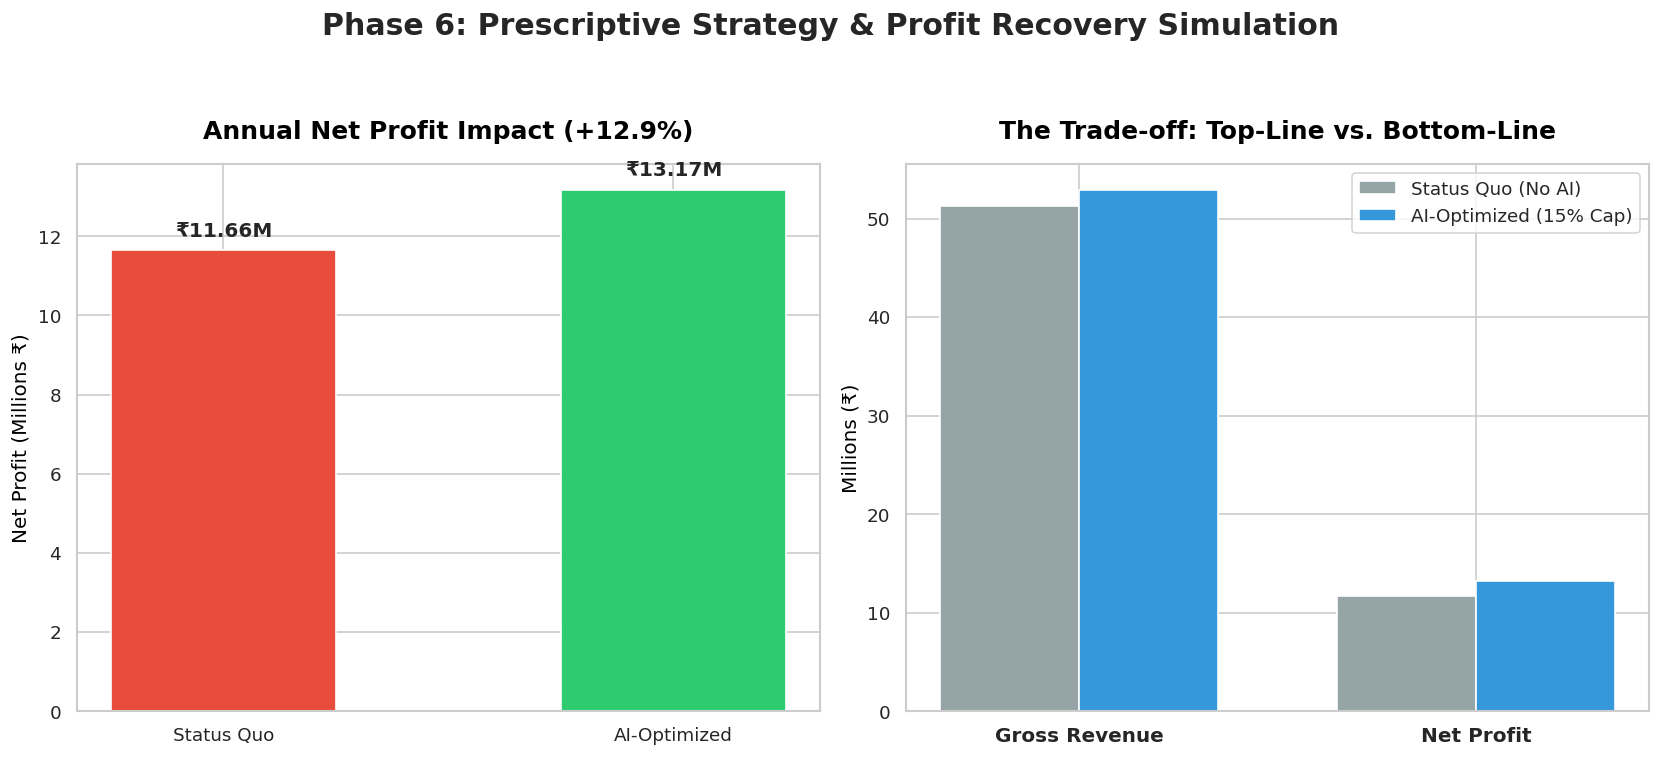

In [ ]:
# PHASE 6 | BLOCK 23: PROFIT RECOVERY SIMULATION (EXECUTIVE DASHBOARD)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Isolate the Test Set (Our Real-World Holdout of 2,000 transactions)
test_df = df.loc[X_test.index].copy()
test_df['predicted_risk'] = y_pred_xgb # Predictions from our best model (XGBoost)

# 2. Calculate Current Financials (Status Quo)
current_revenue = test_df['sales_revenue'].sum()
current_profit = test_df['pocket_profit'].sum()

# 3. Apply the AI Governance Rule:
# IF the AI predicts a Margin Loss AND the discount is > 15%, CAP the discount at 15%.
opt_df = test_df.copy()
intervention_mask = (opt_df['predicted_risk'] == 1) & (opt_df['discount_rate'] > 0.15)

# Apply the Cap
opt_df.loc[intervention_mask, 'discount_rate'] = 0.15

# Recalculate Financial Waterfall with the capped discounts
opt_df['sales_revenue'] = opt_df['list_price'] * (1 - opt_df['discount_rate'])
opt_df['expected_return_cost'] = opt_df['sales_revenue'] * opt_df['return_probability']
opt_df['total_cost'] = opt_df['cogs_amount'] + opt_df['shipping_cost'] + opt_df['expected_return_cost']
opt_df['pocket_profit'] = opt_df['sales_revenue'] - opt_df['total_cost']

# 4. Calculate Optimized Financials
opt_revenue = opt_df['sales_revenue'].sum()
opt_profit = opt_df['pocket_profit'].sum()

profit_uplift = opt_profit - current_profit
profit_uplift_pct = (profit_uplift / current_profit) * 100

# Convert to Millions for executive presentation (extrapolating the test set to an annual view)
millions_factor = 1_000_000
annual_multiplier = 12 # Assuming the test set is 1 month of data

# 5. Build the 1x2 Executive Dashboard
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart A: The Profit Jump
bars = axes[0].bar(['Status Quo', 'AI-Optimized'],
                   [(current_profit * annual_multiplier) / millions_factor,
                    (opt_profit * annual_multiplier) / millions_factor],
                   color=['#e74c3c', '#2ecc71'], width=0.5)

axes[0].set_title(f'Annual Net Profit Impact (+{profit_uplift_pct:.1f}%)', fontsize=15, color='black', pad=15, fontweight='bold')
axes[0].set_ylabel('Net Profit (Millions ₹)', fontsize=12, color='black')

# Add data labels
for bar in bars:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02),
                 f'₹{yval:.2f}M', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Chart B: The Trade-off (Revenue vs Profit)
metrics = ['Gross Revenue', 'Net Profit']
status_quo_vals = [(current_revenue * annual_multiplier) / millions_factor, (current_profit * annual_multiplier) / millions_factor]
opt_vals = [(opt_revenue * annual_multiplier) / millions_factor, (opt_profit * annual_multiplier) / millions_factor]

x = np.arange(len(metrics))
width = 0.35

axes[1].bar(x - width/2, status_quo_vals, width, label='Status Quo (No AI)', color='#95a5a6')
axes[1].bar(x + width/2, opt_vals, width, label='AI-Optimized (15% Cap)', color='#3498db')

axes[1].set_title('The Trade-off: Top-Line vs. Bottom-Line', fontsize=15, color='black', pad=15, fontweight='bold')
axes[1].set_ylabel('Millions (₹)', fontsize=12, color='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('Phase 6: Prescriptive Strategy & Profit Recovery Simulation', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
# PHASE 6 | BLOCK 24: LIVE CRM GOVERNANCE MOCKUP
import pandas as pd

# Extract a few transactions where the AI intervened
crm_view = opt_df[intervention_mask][['customer_id', 'segment', 'list_price']].head(5).copy()

# Format the data to look like a live system output
crm_view['Original_Req_Discount'] = test_df.loc[crm_view.index, 'discount_rate'].apply(lambda x: f"{x*100:.1f}%")
crm_view['AI_Risk_Prediction'] = "🚨 HIGH (MARGIN LOSS)"
crm_view['System_Action_Taken'] = "⚠️ CAPPED AT 15.0%"

# Calculate exact Rupees saved on that single transaction
saved_rupees = opt_df.loc[crm_view.index, 'pocket_profit'] - test_df.loc[crm_view.index, 'pocket_profit']
crm_view['Profit_Saved'] = saved_rupees.apply(lambda x: f"+ ₹{x:.2f}")

print("="*85)
print(" LIVE PRICING GOVERNANCE: CRM / POS INTEGRATION MOCKUP")
print("="*85)
print(crm_view.to_string(index=False))
print("="*85)

 LIVE PRICING GOVERNANCE: CRM / POS INTEGRATION MOCKUP
 customer_id       segment   list_price Original_Req_Discount   AI_Risk_Prediction System_Action_Taken Profit_Saved
        1240 Premium Loyal   577.014844                 25.8% 🚨 HIGH (MARGIN LOSS)  ⚠️ CAPPED AT 15.0%     + ₹62.04
        6262    Occasional 10443.223396                 34.4% 🚨 HIGH (MARGIN LOSS)  ⚠️ CAPPED AT 15.0%   + ₹1920.41
        3743    Occasional  1593.979199                 26.3% 🚨 HIGH (MARGIN LOSS)  ⚠️ CAPPED AT 15.0%    + ₹169.39
        6382 Regular Buyer  1421.690718                 23.6% 🚨 HIGH (MARGIN LOSS)  ⚠️ CAPPED AT 15.0%    + ₹118.21
        1283   Deal Hunter  4388.862065                 27.9% 🚨 HIGH (MARGIN LOSS)  ⚠️ CAPPED AT 15.0%    + ₹564.19
